# 06 — Evaluation against COCO Ground Truth

This notebook evaluates the **adaptive Canny / gap-boundary pipeline** against the COCO annotations exported from Roboflow.

It uses:

- predictions from `outputs/05_metric/measurements.json`
- calibration from `outputs/02_rectified/calibration.json`
- ground truth from `_annotations.coco.json`

The evaluation is focused on the `cut_edge` class.

Main outputs:

- detection metrics: Precision, Recall, F1, mean IoU
- metric accuracy: MAE, RMSE, MAPE and distance error in mm
- per-image and per-gap CSV files
- visual overlays comparing GT and predictions


In [31]:
from pathlib import Path
import json
import math
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from pycocotools import mask as mask_utils
    HAS_PYCOCOTOOLS = True
except Exception:
    HAS_PYCOCOTOOLS = False

print('pycocotools available:', HAS_PYCOCOTOOLS)


pycocotools available: True


## 1. Paths and configuration

In [32]:
# ── Input paths ──────────────────────────────────────────────────────────────
RECTIFIED_DIR = Path('outputs/02_rectified')
CALIB_PATH = RECTIFIED_DIR / 'calibration.json'
MEASUREMENTS_PATH = Path('outputs/05_metric/measurements.json')
COCO_GT_PATH = Path('labels/_annotations.coco.json')

# ── Output paths ─────────────────────────────────────────────────────────────
OUTPUT_DIR = Path('outputs/06_evaluation')
DEBUG_DIR = OUTPUT_DIR / 'debug'
OVERLAY_DIR = DEBUG_DIR / 'gt_prediction_overlays'
for d in [OUTPUT_DIR, DEBUG_DIR, OVERLAY_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CUT_EDGE_CATEGORY_NAME = 'cut_edge'
IOU_THRESHOLDS = [0.30, 0.50]
PRIMARY_IOU_THRESHOLD = 0.30
TRANSFORM_GT_TO_RECTIFIED = True
ALLOW_RESIZE_FALLBACK = True

print('Rectified dir:', RECTIFIED_DIR.resolve())
print('Calibration:', CALIB_PATH.resolve())
print('Measurements:', MEASUREMENTS_PATH.resolve())
print('COCO GT:', COCO_GT_PATH.resolve())
print('Output dir:', OUTPUT_DIR.resolve())


Rectified dir: C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\02_rectified
Calibration: C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\02_rectified\calibration.json
Measurements: C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\05_metric\measurements.json
COCO GT: C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\labels\_annotations.coco.json
Output dir: C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\06_evaluation


## 2. Helper functions

In [33]:
def normalize_image_name(name: str) -> str:
    """Normalize Roboflow / local filenames to the same format."""
    name = Path(str(name)).name
    name = name.replace('Multimedia (', 'Multimedia_').replace(')', '')
    name = name.replace(' ', '_')
    return name


def load_json(path: Path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def bbox_xywh_to_xyxy(b):
    x, y, w, h = map(float, b)
    return np.array([x, y, x + w, y + h], dtype=np.float32)


def bbox_xyxy_to_xywh(b):
    x1, y1, x2, y2 = map(float, b)
    return np.array([x1, y1, x2 - x1, y2 - y1], dtype=np.float32)


def bbox_area_xyxy(b):
    x1, y1, x2, y2 = map(float, b)
    return max(0.0, x2 - x1) * max(0.0, y2 - y1)


def bbox_iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = map(float, a)
    bx1, by1, bx2, by2 = map(float, b)
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    inter = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)
    union = bbox_area_xyxy(a) + bbox_area_xyxy(b) - inter
    return inter / union if union > 0 else 0.0


def transform_points_affine(points_xy, A):
    pts = np.asarray(points_xy, dtype=np.float32)
    ones = np.ones((pts.shape[0], 1), dtype=np.float32)
    homo = np.hstack([pts, ones])
    return homo @ np.asarray(A, dtype=np.float32).T


def transform_bbox_affine_xywh(bbox_xywh, A):
    x, y, w, h = map(float, bbox_xywh)
    corners = np.array([[x, y], [x + w, y], [x + w, y + h], [x, y + h]], dtype=np.float32)
    pts = transform_points_affine(corners, A)
    x1, y1 = pts.min(axis=0)
    x2, y2 = pts.max(axis=0)
    return np.array([x1, y1, x2, y2], dtype=np.float32)


def resize_bbox_to_rectified_xywh(bbox_xywh, orig_w, orig_h, rect_size=800):
    x, y, w, h = map(float, bbox_xywh)
    sx = rect_size / float(orig_w)
    sy = rect_size / float(orig_h)
    return np.array([x * sx, y * sy, (x + w) * sx, (y + h) * sy], dtype=np.float32)


def gap_orientation_from_bbox_xyxy(b):
    x1, y1, x2, y2 = map(float, b)
    return 'vertical' if (y2 - y1) >= (x2 - x1) else 'horizontal'


def gap_width_from_bbox_xyxy(b):
    x1, y1, x2, y2 = map(float, b)
    return float(min(max(0, x2 - x1), max(0, y2 - y1)))


def greedy_match(pred_boxes, gt_boxes, iou_threshold=0.3):
    candidates = []
    for pi, pb in enumerate(pred_boxes):
        for gi, gb in enumerate(gt_boxes):
            iou = bbox_iou_xyxy(pb, gb)
            if iou >= iou_threshold:
                candidates.append((iou, pi, gi))
    candidates.sort(reverse=True, key=lambda t: t[0])
    used_p, used_g, matches = set(), set(), []
    for iou, pi, gi in candidates:
        if pi in used_p or gi in used_g:
            continue
        used_p.add(pi); used_g.add(gi); matches.append((pi, gi, iou))
    unmatched_pred = [i for i in range(len(pred_boxes)) if i not in used_p]
    unmatched_gt = [i for i in range(len(gt_boxes)) if i not in used_g]
    return matches, unmatched_pred, unmatched_gt


def safe_div(a, b):
    return float(a / b) if b else 0.0


## 3. Load predictions, calibration and COCO ground truth

In [34]:
measurements = load_json(MEASUREMENTS_PATH)
calibration = load_json(CALIB_PATH) if CALIB_PATH.exists() else {}
coco = load_json(COCO_GT_PATH)

print(f'Prediction images: {len(measurements)}')
print(f'Calibration images: {len(calibration)}')
print(f'COCO images: {len(coco.get("images", []))}')
print(f'COCO annotations: {len(coco.get("annotations", []))}')

categories = {cat['id']: cat['name'] for cat in coco['categories']}
name_to_category_id = {v: k for k, v in categories.items()}
CUT_EDGE_CATEGORY_ID = name_to_category_id[CUT_EDGE_CATEGORY_NAME]
print('cut_edge category id:', CUT_EDGE_CATEGORY_ID)


Prediction images: 20
Calibration images: 20
COCO images: 22
COCO annotations: 98
cut_edge category id: 1


## 4. Build GT table in rectified metric coordinates

Roboflow annotations are in the **original image coordinate system**, while our predictions are in the **rectified 800×800 metric image**. Therefore, each GT bbox is transformed using `A_image_to_metric` from `calibration.json`.


In [35]:
image_id_to_info = {}
for img in coco['images']:
    img = dict(img)
    img['norm_file_name'] = normalize_image_name(img['file_name'])
    image_id_to_info[img['id']] = img

gt_by_image = defaultdict(list)
gt_rows = []
missing_calibration = []

for ann in coco['annotations']:
    if ann['category_id'] != CUT_EDGE_CATEGORY_ID:
        continue
    img_info = image_id_to_info[ann['image_id']]
    image_name = normalize_image_name(img_info['file_name'])
    bbox_orig_xywh = [float(v) for v in ann['bbox']]
    calib = calibration.get(image_name)

    if TRANSFORM_GT_TO_RECTIFIED and calib is not None and 'A_image_to_metric' in calib:
        bbox_rect_xyxy = transform_bbox_affine_xywh(bbox_orig_xywh, calib['A_image_to_metric'])
        transform_mode = 'affine_metric'
    elif ALLOW_RESIZE_FALLBACK:
        bbox_rect_xyxy = resize_bbox_to_rectified_xywh(bbox_orig_xywh, img_info['width'], img_info['height'], 800)
        transform_mode = 'resize_fallback'
        missing_calibration.append(image_name)
    else:
        missing_calibration.append(image_name)
        continue

    bbox_rect_xyxy = np.array([
        np.clip(bbox_rect_xyxy[0], 0, 800), np.clip(bbox_rect_xyxy[1], 0, 800),
        np.clip(bbox_rect_xyxy[2], 0, 800), np.clip(bbox_rect_xyxy[3], 0, 800)
    ], dtype=np.float32)

    gt_item = {
        'image_name': image_name,
        'annotation_id': ann['id'],
        'category_id': ann['category_id'],
        'category_name': categories[ann['category_id']],
        'bbox_orig_xywh': bbox_orig_xywh,
        'bbox_rect_xyxy': bbox_rect_xyxy.tolist(),
        'bbox_rect_xywh': bbox_xyxy_to_xywh(bbox_rect_xyxy).tolist(),
        'gt_orientation': gap_orientation_from_bbox_xyxy(bbox_rect_xyxy),
        'gt_width_mm': gap_width_from_bbox_xyxy(bbox_rect_xyxy),
        'gt_area_rect': bbox_area_xyxy(bbox_rect_xyxy),
        'transform_mode': transform_mode,
    }
    gt_by_image[image_name].append(gt_item)
    gt_rows.append(gt_item)

gt_df = pd.DataFrame(gt_rows)
print(f'GT cut_edge annotations: {len(gt_df)}')
print('Images with GT cut_edge:', gt_df['image_name'].nunique())
print('Transform modes:')
print(gt_df['transform_mode'].value_counts())
if missing_calibration:
    print('WARNING: missing calibration, resize fallback used for:')
    print(sorted(set(missing_calibration)))
gt_df.head()


GT cut_edge annotations: 34
Images with GT cut_edge: 17
Transform modes:
transform_mode
affine_metric      30
resize_fallback     4
Name: count, dtype: int64
['Multimedia_38.jpg', 'Multimedia_44.jpg']


,image_name,annotation_id,category_id,category_name,bbox_orig_xywh,bbox_rect_xyxy,bbox_rect_xywh,gt_orientation,gt_width_mm,gt_area_rect,transform_mode
0,Multimedia_46.jpg,1,1,cut_edge,"[219.0, 868.0, 333.0, 26.0]","[110.99016571044922, 562.88232421875, 345.6185...","[110.99016571044922, 562.88232421875, 234.6283...",horizontal,22.978271,5391.354960,affine_metric
1,Multimedia_46.jpg,2,1,cut_edge,"[695.0, 867.0, 329.0, 24.0]","[446.2423400878906, 556.6530151367188, 678.045...","[446.2423400878906, 556.6530151367188, 231.803...",horizontal,21.462341,4975.045776,affine_metric
2,Multimedia_43.jpg,9,1,cut_edge,"[399.0, 264.0, 13.0, 366.0]","[218.64453125, 114.833251953125, 235.196441650...","[218.64453125, 114.833251953125, 16.5519104003...",vertical,16.551910,3903.527730,affine_metric
3,Multimedia_43.jpg,10,1,cut_edge,"[407.0, 783.0, 20.0, 340.0]","[235.38265991210938, 449.0662536621094, 255.87...","[235.38265991210938, 449.0662536621094, 20.488...",vertical,20.488861,4491.690705,affine_metric
4,Multimedia_31.jpg,11,1,cut_edge,"[321.0, 160.0, 30.0, 393.0]","[168.18663024902344, 78.78909301757812, 197.73...","[168.18663024902344, 78.78909301757812, 29.545...",vertical,29.545563,7296.103060,affine_metric


## 5. Build prediction table

In [36]:
pred_by_image = defaultdict(list)
pred_rows = []

for image_name, data in measurements.items():
    image_name = normalize_image_name(image_name)
    px_per_mm = float(data.get('px_per_mm', 1.0))
    for m in data.get('measurements', []):
        bbox_xywh = m.get('bbox_px') or [m.get('bbox_x_px'), m.get('bbox_y_px'), m.get('bbox_w_px'), m.get('bbox_h_px')]
        if any(v is None for v in bbox_xywh):
            continue
        bbox_xyxy = bbox_xywh_to_xyxy(bbox_xywh)
        recommended = m.get('recommended_distance_mm')
        if recommended is None:
            recommended = m.get('trimmed_mean_distance_mm', m.get('median_distance_mm', m.get('mean_distance_mm')))
        pred_item = {
            'image_name': image_name,
            'gap_id': int(m.get('gap_id', len(pred_by_image[image_name]))),
            'gap_index': int(m.get('gap_index', len(pred_by_image[image_name]))),
            'orientation': m.get('orientation', gap_orientation_from_bbox_xyxy(bbox_xyxy)),
            'bbox_pred_xyxy': bbox_xyxy.tolist(),
            'bbox_pred_xywh': bbox_xywh,
            'pred_width_mm': float(recommended) if recommended is not None else np.nan,
            'pred_bbox_thickness_mm': gap_width_from_bbox_xyxy(bbox_xyxy) / px_per_mm,
            'score': float(m.get('score', 1.0)),
            'quality_status': m.get('quality_status', ''),
            'quality_reasons': m.get('quality_reasons', ''),
            'robust_cv_distance': float(m.get('robust_cv_distance', np.nan)),
            'mean_distance_mm': float(m.get('mean_distance_mm', np.nan)),
            'median_distance_mm': float(m.get('median_distance_mm', np.nan)),
            'trimmed_mean_distance_mm': float(m.get('trimmed_mean_distance_mm', np.nan)),
            'recommended_distance_mm': float(recommended) if recommended is not None else np.nan,
            'n_valid_samples': int(m.get('n_valid_samples', 0)),
        }
        pred_by_image[image_name].append(pred_item)
        pred_rows.append(pred_item)

pred_df = pd.DataFrame(pred_rows)
print(f'Predicted gaps: {len(pred_df)}')
print('Images with predictions:', pred_df['image_name'].nunique())
pred_df.head()


Predicted gaps: 32
Images with predictions: 15


,image_name,gap_id,gap_index,orientation,bbox_pred_xyxy,bbox_pred_xywh,pred_width_mm,pred_bbox_thickness_mm,score,quality_status,quality_reasons,robust_cv_distance,mean_distance_mm,median_distance_mm,trimmed_mean_distance_mm,recommended_distance_mm,n_valid_samples
0,Multimedia_31.jpg,0,0,vertical,"[170.0, 82.0, 188.0, 325.0]","[170, 82, 18, 243]",6.474203,18.0,725.603204,,,0.528225,6.750789,6.396821,6.474203,6.474203,10
1,Multimedia_31.jpg,1,1,vertical,"[183.0, 538.0, 205.0, 692.0]","[183, 538, 22, 154]",7.357143,22.0,516.748386,,,0.384568,7.228572,7.285713,7.357143,7.357143,10
2,Multimedia_32.jpg,0,0,vertical,"[157.0, 77.0, 175.0, 243.0]","[157, 77, 18, 166]",5.970235,18.0,537.449153,,,0.467331,6.119045,5.547622,5.970235,5.970235,10
3,Multimedia_32.jpg,1,1,vertical,"[183.0, 514.0, 204.0, 637.0]","[183, 514, 21, 123]",6.246035,21.0,435.411965,,,0.368349,6.139686,5.984128,6.246035,6.246035,10
4,Multimedia_33.jpg,0,0,vertical,"[184.0, 91.0, 200.0, 339.0]","[184, 91, 16, 248]",6.188489,16.0,732.017732,,,0.520318,6.393650,5.500000,6.188489,6.188489,10


## 6. Match predictions with ground truth and compute metrics

In [37]:
def evaluate_at_iou_threshold(iou_thr):
    image_rows, match_rows = [], []
    all_image_names = sorted(set(gt_by_image.keys()) | set(pred_by_image.keys()))
    total_tp = total_fp = total_fn = 0
    all_match_ious, all_abs_errors, all_sq_errors, all_rel_errors = [], [], [], []

    for image_name in all_image_names:
        preds = pred_by_image.get(image_name, [])
        gts = gt_by_image.get(image_name, [])
        pred_boxes = [p['bbox_pred_xyxy'] for p in preds]
        gt_boxes = [g['bbox_rect_xyxy'] for g in gts]
        matches, unmatched_pred, unmatched_gt = greedy_match(pred_boxes, gt_boxes, iou_threshold=iou_thr)
        tp, fp, fn = len(matches), len(unmatched_pred), len(unmatched_gt)
        total_tp += tp; total_fp += fp; total_fn += fn
        image_ious, image_abs_errors = [], []

        for pred_idx, gt_idx, iou in matches:
            p, g = preds[pred_idx], gts[gt_idx]
            pred_width = float(p['pred_width_mm'])
            gt_width = float(g['gt_width_mm'])
            abs_error = abs(pred_width - gt_width)
            sq_error = abs_error ** 2
            rel_error = abs_error / gt_width if gt_width > 1e-6 else np.nan
            image_ious.append(iou); image_abs_errors.append(abs_error)
            all_match_ious.append(iou); all_abs_errors.append(abs_error); all_sq_errors.append(sq_error)
            if not np.isnan(rel_error):
                all_rel_errors.append(rel_error)
            match_rows.append({
                'iou_threshold': iou_thr,
                'image_name': image_name,
                'pred_gap_id': p['gap_id'],
                'gt_annotation_id': g['annotation_id'],
                'iou': iou,
                'pred_orientation': p['orientation'],
                'gt_orientation': g['gt_orientation'],
                'pred_width_mm': pred_width,
                'gt_width_mm': gt_width,
                'abs_error_mm': abs_error,
                'sq_error_mm2': sq_error,
                'relative_error': rel_error,
                'relative_error_percent': rel_error * 100 if not np.isnan(rel_error) else np.nan,
                'pred_quality_status': p['quality_status'],
                'pred_quality_reasons': p['quality_reasons'],
                'pred_robust_cv_distance': p['robust_cv_distance'],
                'pred_bbox_xyxy': p['bbox_pred_xyxy'],
                'gt_bbox_xyxy': g['bbox_rect_xyxy'],
            })

        precision_img = safe_div(tp, tp + fp)
        recall_img = safe_div(tp, tp + fn)
        f1_img = safe_div(2 * precision_img * recall_img, precision_img + recall_img)
        image_rows.append({
            'iou_threshold': iou_thr,
            'image_name': image_name,
            'n_gt': len(gts),
            'n_pred': len(preds),
            'tp': tp, 'fp': fp, 'fn': fn,
            'precision': precision_img,
            'recall': recall_img,
            'f1': f1_img,
            'mean_iou_matches': float(np.mean(image_ious)) if image_ious else np.nan,
            'mae_mm': float(np.mean(image_abs_errors)) if image_abs_errors else np.nan,
            'quality_status': 'ok' if fp == 0 and fn == 0 else 'warning',
            'quality_reasons': ';'.join([x for x in ['false_positives' if fp > 0 else '', 'false_negatives' if fn > 0 else ''] if x]),
        })

    precision = safe_div(total_tp, total_tp + total_fp)
    recall = safe_div(total_tp, total_tp + total_fn)
    f1 = safe_div(2 * precision * recall, precision + recall)
    summary = {
        'iou_threshold': iou_thr,
        'n_images_evaluated': len(all_image_names),
        'n_gt_total': int(sum(len(v) for v in gt_by_image.values())),
        'n_pred_total': int(sum(len(v) for v in pred_by_image.values())),
        'tp': int(total_tp), 'fp': int(total_fp), 'fn': int(total_fn),
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'mean_iou_matches': float(np.mean(all_match_ious)) if all_match_ious else 0.0,
        'mae_mm': float(np.mean(all_abs_errors)) if all_abs_errors else np.nan,
        'rmse_mm': float(math.sqrt(np.mean(all_sq_errors))) if all_sq_errors else np.nan,
        'mape_percent': float(np.mean(all_rel_errors) * 100) if all_rel_errors else np.nan,
    }
    return summary, pd.DataFrame(image_rows), pd.DataFrame(match_rows)

all_summaries, image_eval_tables, match_tables = [], [], []
for thr in IOU_THRESHOLDS:
    summary, image_df_thr, match_df_thr = evaluate_at_iou_threshold(thr)
    all_summaries.append(summary)
    image_eval_tables.append(image_df_thr)
    match_tables.append(match_df_thr)

summary_df = pd.DataFrame(all_summaries)
image_eval_df = pd.concat(image_eval_tables, ignore_index=True)
match_eval_df = pd.concat(match_tables, ignore_index=True)
summary_df


,iou_threshold,n_images_evaluated,n_gt_total,n_pred_total,tp,fp,fn,precision,recall,f1,mean_iou_matches,mae_mm,rmse_mm,mape_percent
0,0.3,17,34,32,25,7,9,0.78125,0.735294,0.757576,0.620725,21.062226,23.019803,69.942938
1,0.5,17,34,32,17,15,17,0.53125,0.500000,0.515152,0.715787,17.350516,18.521194,64.856239


## 7. Primary summary

In [38]:
primary_summary = summary_df[summary_df['iou_threshold'] == PRIMARY_IOU_THRESHOLD].iloc[0].to_dict()
primary_image_eval = image_eval_df[image_eval_df['iou_threshold'] == PRIMARY_IOU_THRESHOLD].copy()
primary_matches = match_eval_df[match_eval_df['iou_threshold'] == PRIMARY_IOU_THRESHOLD].copy()

print('Primary IoU threshold:', PRIMARY_IOU_THRESHOLD)
for k, v in primary_summary.items():
    print(f'{k}: {v}')


Primary IoU threshold: 0.3
iou_threshold: 0.3
n_images_evaluated: 17.0
n_gt_total: 34.0
n_pred_total: 32.0
tp: 25.0
fp: 7.0
fn: 9.0
precision: 0.78125
recall: 0.7352941176470589
f1: 0.7575757575757576
mean_iou_matches: 0.6207248885003945
mae_mm: 21.062225704193114
rmse_mm: 23.019803456974046
mape_percent: 69.9429383397693


## 8. Save CSV/JSON reports

In [39]:
summary_df.to_csv(OUTPUT_DIR / 'coco_gt_summary_by_iou.csv', index=False)
primary_image_eval.to_csv(OUTPUT_DIR / 'coco_gt_image_level_evaluation.csv', index=False)
primary_matches.to_csv(OUTPUT_DIR / 'coco_gt_matched_predictions.csv', index=False)
gt_df.to_csv(OUTPUT_DIR / 'coco_gt_cut_edges_rectified.csv', index=False)
pred_df.to_csv(OUTPUT_DIR / 'coco_predicted_gaps.csv', index=False)

report = {
    'primary_iou_threshold': PRIMARY_IOU_THRESHOLD,
    'summary_by_iou': summary_df.to_dict(orient='records'),
    'primary_summary': primary_summary,
    'notes': {
        'gt_source': str(COCO_GT_PATH),
        'predictions_source': str(MEASUREMENTS_PATH),
        'calibration_source': str(CALIB_PATH),
        'gt_transform': 'A_image_to_metric from calibration.json when available',
        'primary_metric_value': 'recommended_distance_mm from NB05',
    }
}
with open(OUTPUT_DIR / 'coco_gt_report.json', 'w', encoding='utf-8') as f:
    json.dump(report, f, indent=2)
print('Saved evaluation outputs to:', OUTPUT_DIR.resolve())


Saved evaluation outputs to: C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\06_evaluation


## 9. Visual summary plots

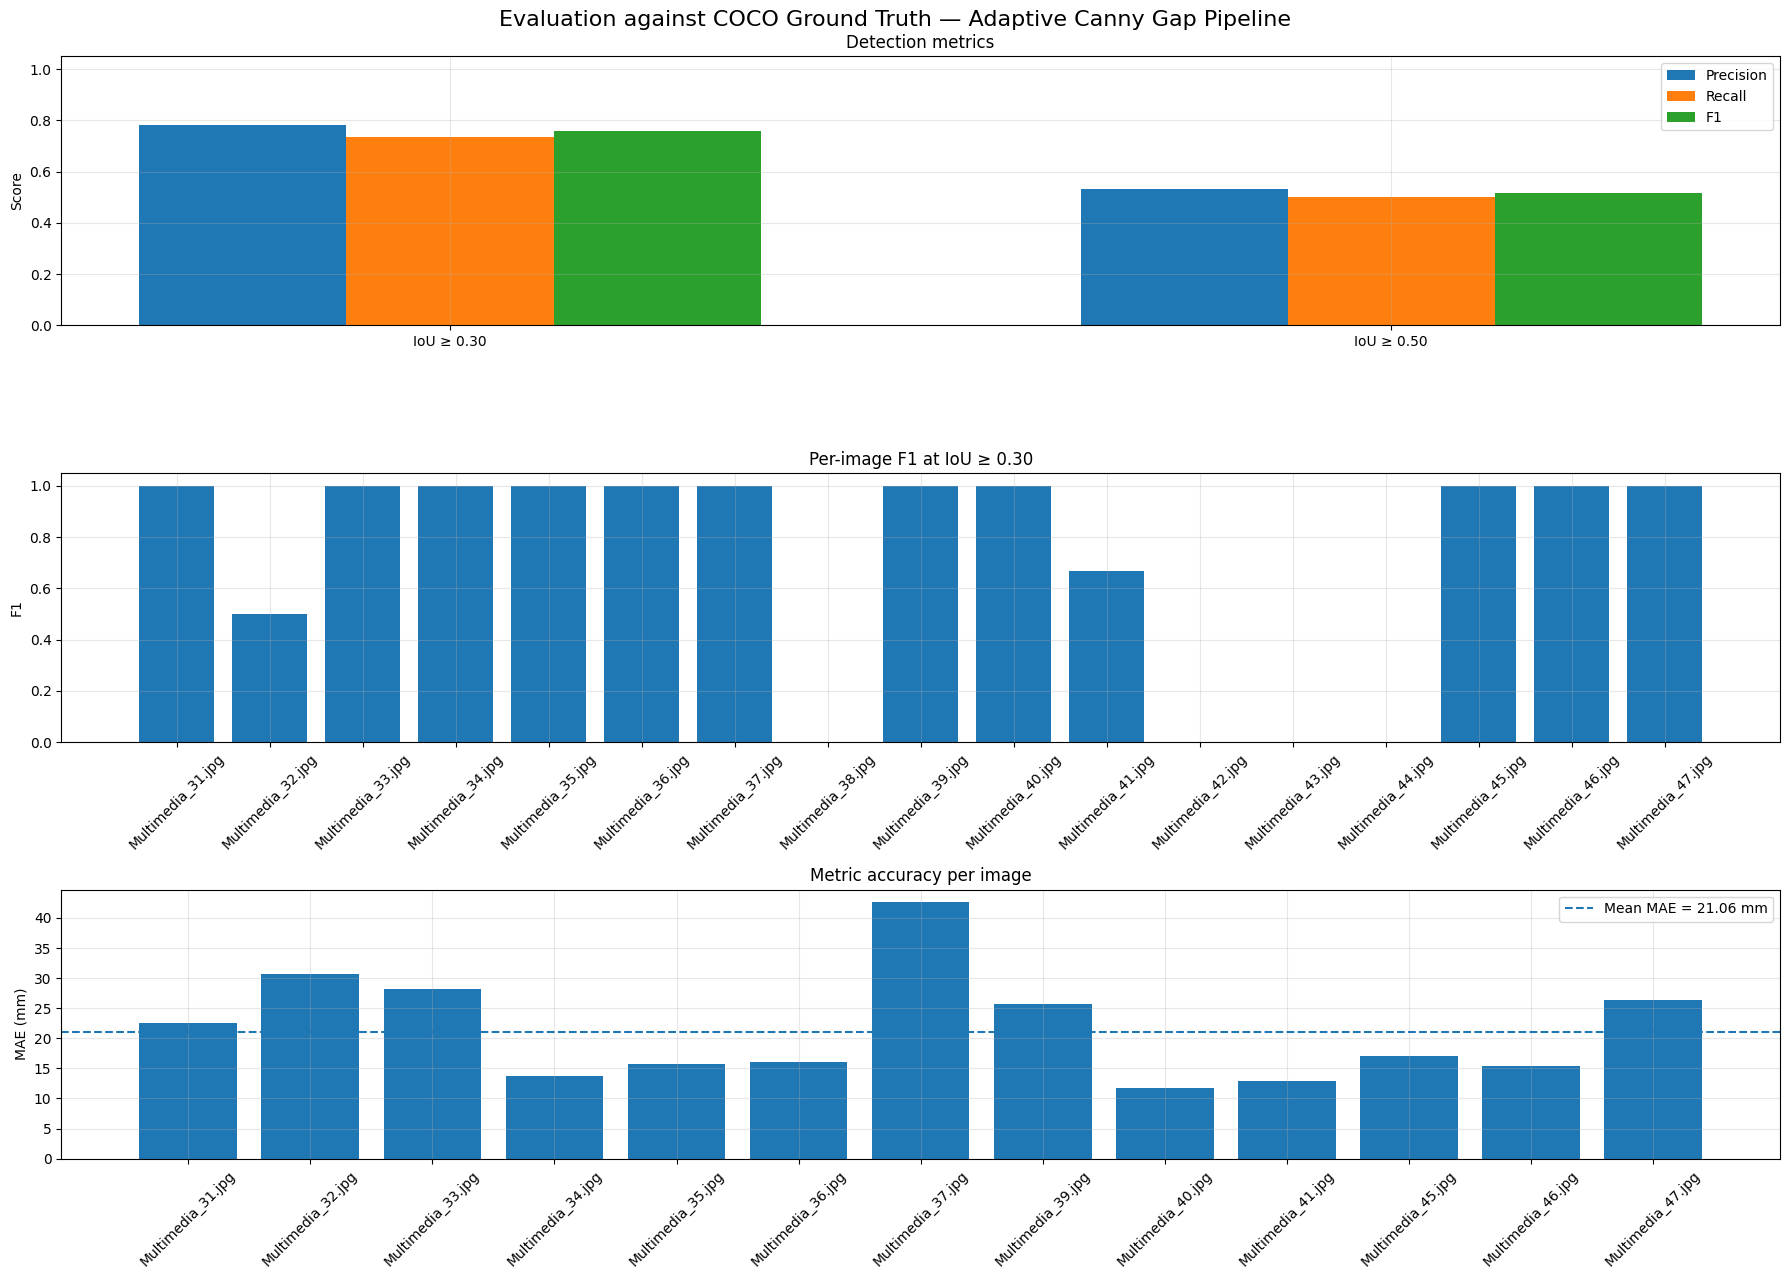

In [40]:
fig, axes = plt.subplots(3, 1, figsize=(18, 13))
fig.suptitle('Evaluation against COCO Ground Truth — Adaptive Canny Gap Pipeline', fontsize=16)

x = np.arange(len(summary_df))
labels = [f'IoU ≥ {t:.2f}' for t in summary_df['iou_threshold']]
width = 0.22
axes[0].bar(x - width, summary_df['precision'], width, label='Precision')
axes[0].bar(x, summary_df['recall'], width, label='Recall')
axes[0].bar(x + width, summary_df['f1'], width, label='F1')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel('Score')
axes[0].set_title('Detection metrics'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

plot_df = primary_image_eval.sort_values('image_name')
axes[1].bar(plot_df['image_name'], plot_df['f1'])
axes[1].set_ylim(0, 1.05); axes[1].set_ylabel('F1')
axes[1].set_title(f'Per-image F1 at IoU ≥ {PRIMARY_IOU_THRESHOLD:.2f}')
axes[1].tick_params(axis='x', rotation=45); axes[1].grid(True, alpha=0.3)

if len(primary_matches) > 0:
    err_df = primary_matches.groupby('image_name')['abs_error_mm'].mean().reset_index()
    axes[2].bar(err_df['image_name'], err_df['abs_error_mm'])
    axes[2].axhline(primary_summary['mae_mm'], linestyle='--', label=f"Mean MAE = {primary_summary['mae_mm']:.2f} mm")
    axes[2].legend()
axes[2].set_ylabel('MAE (mm)')
axes[2].set_title('Metric accuracy per image')
axes[2].tick_params(axis='x', rotation=45); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'coco_gt_evaluation_summary.png', dpi=180, bbox_inches='tight')
plt.show()


## 10. GT vs prediction overlays

Green boxes = ground truth `cut_edge` annotations.  
Red boxes = unmatched predicted gaps.  
Yellow boxes = matched predictions with IoU label.


In [41]:
def draw_bbox(ax, b, color, label=None, linewidth=2):
    x1, y1, x2, y2 = map(float, b)
    rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor=color, linewidth=linewidth)
    ax.add_patch(rect)
    if label:
        ax.text(x1, max(0, y1 - 4), label, color=color, fontsize=8, fontweight='bold')


def save_overlay_for_image(image_name):
    img_path = RECTIFIED_DIR / image_name
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return False
    gts = gt_by_image.get(image_name, [])
    preds = pred_by_image.get(image_name, [])
    pred_boxes = [p['bbox_pred_xyxy'] for p in preds]
    gt_boxes = [g['bbox_rect_xyxy'] for g in gts]
    matches, unmatched_pred, unmatched_gt = greedy_match(pred_boxes, gt_boxes, PRIMARY_IOU_THRESHOLD)

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{image_name} — TP={len(matches)} FP={len(unmatched_pred)} FN={len(unmatched_gt)}')
    for g in gts:
        draw_bbox(ax, g['bbox_rect_xyxy'], 'lime', label=f'GT {g["annotation_id"]}', linewidth=2)
    matched_pred_indices = {m[0]: m for m in matches}
    for i, p in enumerate(preds):
        if i in matched_pred_indices:
            _, gt_idx, iou = matched_pred_indices[i]
            draw_bbox(ax, p['bbox_pred_xyxy'], 'yellow', label=f'P{p["gap_id"]} IoU={iou:.2f}', linewidth=2.5)
        else:
            draw_bbox(ax, p['bbox_pred_xyxy'], 'red', label=f'P{p["gap_id"]} FP', linewidth=2)
    ax.axis('off')
    plt.tight_layout()
    out_path = OVERLAY_DIR / f'{Path(image_name).stem}_gt_pred_overlay.png'
    plt.savefig(out_path, dpi=160, bbox_inches='tight')
    plt.close(fig)
    return True

n_saved = 0
for image_name in sorted(set(gt_by_image.keys()) | set(pred_by_image.keys())):
    if save_overlay_for_image(image_name):
        n_saved += 1
print(f'Saved {n_saved} overlays to {OVERLAY_DIR.resolve()}')


Saved 15 overlays to C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\06_evaluation\debug\gt_prediction_overlays


## 11. AP-like curve from geometric scores

The classical pipeline does not output a neural confidence, but it saves a geometric score. This section computes an AP-like curve by sorting detections by that score.


AP-like at IoU ≥ 0.30: 0.7285


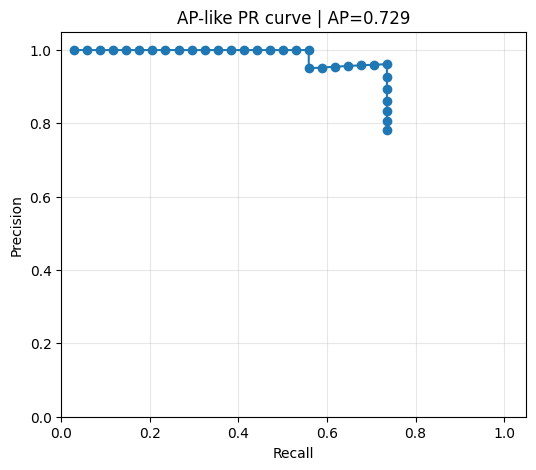

In [42]:
def compute_ap_like(iou_thr=0.3):
    preds_flat = []
    for image_name, preds in pred_by_image.items():
        for local_idx, p in enumerate(preds):
            preds_flat.append((image_name, local_idx, p))
    preds_flat.sort(key=lambda t: float(t[2].get('score', 0.0)), reverse=True)
    gt_used = {image_name: set() for image_name in gt_by_image.keys()}
    n_gt = sum(len(v) for v in gt_by_image.values())
    tp_list, fp_list = [], []
    for image_name, local_idx, p in preds_flat:
        gts = gt_by_image.get(image_name, [])
        best_iou, best_gt_idx = 0.0, None
        for gi, g in enumerate(gts):
            if gi in gt_used.setdefault(image_name, set()):
                continue
            iou = bbox_iou_xyxy(p['bbox_pred_xyxy'], g['bbox_rect_xyxy'])
            if iou > best_iou:
                best_iou, best_gt_idx = iou, gi
        if best_iou >= iou_thr and best_gt_idx is not None:
            tp_list.append(1); fp_list.append(0); gt_used[image_name].add(best_gt_idx)
        else:
            tp_list.append(0); fp_list.append(1)
    if n_gt == 0 or len(tp_list) == 0:
        return np.nan, pd.DataFrame()
    tp_cum, fp_cum = np.cumsum(tp_list), np.cumsum(fp_list)
    recall = tp_cum / n_gt
    precision = tp_cum / np.maximum(tp_cum + fp_cum, 1)
    mrec = np.concatenate([[0.0], recall, [1.0]])
    mpre = np.concatenate([[0.0], precision, [0.0]])
    for i in range(len(mpre) - 2, -1, -1):
        mpre[i] = max(mpre[i], mpre[i + 1])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    ap = float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))
    return ap, pd.DataFrame({'precision': precision, 'recall': recall})

ap_like, pr_curve_df = compute_ap_like(PRIMARY_IOU_THRESHOLD)
print(f'AP-like at IoU ≥ {PRIMARY_IOU_THRESHOLD:.2f}: {ap_like:.4f}')
if len(pr_curve_df) > 0:
    pr_curve_df.to_csv(OUTPUT_DIR / 'ap_like_pr_curve.csv', index=False)
    plt.figure(figsize=(6, 5))
    plt.plot(pr_curve_df['recall'], pr_curve_df['precision'], marker='o')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title(f'AP-like PR curve | AP={ap_like:.3f}')
    plt.ylim(0, 1.05); plt.xlim(0, 1.05); plt.grid(True, alpha=0.3)
    plt.savefig(OUTPUT_DIR / 'ap_like_pr_curve.png', dpi=160, bbox_inches='tight')
    plt.show()


## 12. Final report table

In [43]:
report_table = summary_df.copy()
for col in ['precision', 'recall', 'f1', 'mean_iou_matches']:
    report_table[col] = report_table[col].round(4)
for col in ['mae_mm', 'rmse_mm']:
    report_table[col] = report_table[col].round(3)
report_table['mape_percent'] = report_table['mape_percent'].round(2)
report_table.to_csv(OUTPUT_DIR / 'final_report_table.csv', index=False)
report_table


,iou_threshold,n_images_evaluated,n_gt_total,n_pred_total,tp,fp,fn,precision,recall,f1,mean_iou_matches,mae_mm,rmse_mm,mape_percent
0,0.3,17,34,32,25,7,9,0.7812,0.7353,0.7576,0.6207,21.062,23.020,69.94
1,0.5,17,34,32,17,15,17,0.5312,0.5000,0.5152,0.7158,17.351,18.521,64.86


## 13. Interpretation notes

Recommended wording for the report:

> The adaptive Canny pipeline was evaluated against COCO-format ground truth annotations of the `cut_edge` class. Since the predictions are generated after QR-based affine rectification, the ground truth bounding boxes were transformed from the original image coordinates into the same 800×800 metric reference system using the affine calibration matrix. Detection quality was evaluated with IoU-based matching, reporting Precision, Recall and F1-score. Metric accuracy was evaluated by comparing the robust predicted gap width against the transformed ground-truth cut-edge thickness, using MAE, RMSE and MAPE.

Important note: the adaptive Canny pipeline is not a full semantic segmentation model. Therefore, bbox-based evaluation is the fairest comparison, because the method mainly localizes and measures gap/cut-edge regions rather than generating dense masks.
